# 🛒 Retail Sales Analytics
Full EDA pipeline: data cleaning, visualizations, RFM segmentation, and statistical insights.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)
print('All libraries loaded ✅')

All libraries loaded ✅


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('RetailSalesAnalytics.csv')

print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
df.head()

Shape: (1000, 20)

Data Types:
order_id                  str
order_date                str
order_status              str
customer_id               str
customer_segment          str
product_id                str
product_name              str
category                  str
brand                     str
unit_price            float64
quantity_sold           int64
discount              float64
revenue               float64
cost_of_goods_sold    float64
profit                float64
sales_channel             str
region                    str
city                      str
store_id                  str
salesperson_id            str
dtype: object


,order_id,order_date,order_status,customer_id,customer_segment,product_id,product_name,category,brand,unit_price,quantity_sold,discount,revenue,cost_of_goods_sold,profit,sales_channel,region,city,store_id,salesperson_id
0,ORD-10000,2024-10-16,Cancelled,CUST-1044,Loyalty Member,PROD-316,Laptop,Electronics,Sony,518.36,3,0.00,1555.08,962.87,592.21,Online,North,Delhi,STORE-7,SP-114
1,ORD-10001,2024-06-01,Cancelled,CUST-1142,Retail,PROD-488,Fiction Novel,Books,Macmillan,13.95,9,0.20,100.44,50.73,49.71,Online,West,Pune,STORE-9,SP-109
2,ORD-10002,2023-08-09,Completed,CUST-1235,Loyalty Member,PROD-163,Blender,Home & Kitchen,Philips,170.57,6,0.15,869.91,522.76,347.15,In-Store,North,Chennai,STORE-20,SP-123
3,ORD-10003,2024-08-14,Completed,CUST-1194,Wholesale,PROD-332,T-Shirt,Clothing,Nike,139.03,5,0.00,695.15,461.46,233.69,Mobile App,East,Bangalore,STORE-12,SP-122
4,ORD-10004,2023-08-03,Returned,CUST-1138,Loyalty Member,PROD-452,Blender,Home & Kitchen,Cuisinart,264.94,9,0.05,2265.24,1111.89,1153.35,Mobile App,South,Pune,STORE-2,SP-114


In [3]:
print('Missing Values:')
print(df.isnull().sum())
print('\nStatistical Summary:')
df.describe()

Missing Values:
order_id              0
order_date            0
order_status          0
customer_id           0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
unit_price            0
quantity_sold         0
discount              0
revenue               0
cost_of_goods_sold    0
profit                0
sales_channel         0
region                0
city                  0
store_id              0
salesperson_id        0
dtype: int64

Statistical Summary:


,unit_price,quantity_sold,discount,revenue,cost_of_goods_sold,profit
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,272.92,5.49,0.10,1309.74,746.65,563.09
std,333.00,2.85,0.09,1844.85,1066.42,806.79
min,5.58,1.00,0.00,6.01,3.57,2.44
25%,46.60,3.00,0.00,205.85,115.67,89.47
50%,155.43,6.00,0.10,582.16,338.18,248.00
75%,312.34,8.00,0.20,1573.31,870.01,682.61
max,1491.37,10.00,0.25,13388.94,8329.06,6028.40


## 3. Data Cleaning & Feature Engineering

In [4]:
# Parse dates
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract time features
df['year']        = df['order_date'].dt.year
df['month']       = df['order_date'].dt.month
df['quarter']     = df['order_date'].dt.quarter
df['day_of_week'] = df['order_date'].dt.day_name()
df['month_name']  = df['order_date'].dt.strftime('%b')

# Fill missing
df['discount'].fillna(0, inplace=True)
df.dropna(subset=['revenue', 'product_id'], inplace=True)
df.drop_duplicates(subset='order_id', inplace=True)

# Derived metrics
df['profit_margin'] = (df['profit'] / df['revenue']) * 100

print(f'Clean dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head(3)

Clean dataset: 1000 rows, 26 columns


C:\Users\John\AppData\Local\Temp\ipykernel_19876\405467892.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['discount'].fillna(0, inplace=True)


,order_id,order_date,order_status,customer_id,customer_segment,product_id,product_name,category,brand,unit_price,...,region,city,store_id,salesperson_id,year,month,quarter,day_of_week,month_name,profit_margin
0,ORD-10000,2024-10-16,Cancelled,CUST-1044,Loyalty Member,PROD-316,Laptop,Electronics,Sony,518.36,...,North,Delhi,STORE-7,SP-114,2024,10,4,Wednesday,Oct,38.08
1,ORD-10001,2024-06-01,Cancelled,CUST-1142,Retail,PROD-488,Fiction Novel,Books,Macmillan,13.95,...,West,Pune,STORE-9,SP-109,2024,6,2,Saturday,Jun,49.49
2,ORD-10002,2023-08-09,Completed,CUST-1235,Loyalty Member,PROD-163,Blender,Home & Kitchen,Philips,170.57,...,North,Chennai,STORE-20,SP-123,2023,8,3,Wednesday,Aug,39.91


## 4. Revenue Trend Over Time

In [5]:
monthly = df.groupby(['year','month'])['revenue'].sum().reset_index()
monthly['period'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly = monthly.sort_values('period')
monthly['rolling_avg'] = monthly['revenue'].rolling(3).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=monthly['period'], y=monthly['revenue'],
                         name='Monthly Revenue', mode='lines+markers',
                         line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=monthly['period'], y=monthly['rolling_avg'],
                         name='3-Month Rolling Avg',
                         line=dict(dash='dash', color='orange')))
fig.update_layout(title='📈 Monthly Revenue with Rolling Average',
                  xaxis_title='Month', yaxis_title='Revenue ($)',
                  legend=dict(x=0, y=1))
fig.show()

## 5. Revenue by Category

In [6]:
cat_sales = df.groupby('category').agg(
    Revenue=('revenue','sum'),
    Orders=('order_id','count'),
    AvgProfit=('profit_margin','mean')
).reset_index().sort_values('Revenue', ascending=False)

fig = px.bar(cat_sales, x='category', y='Revenue',
             color='AvgProfit', color_continuous_scale='RdYlGn',
             text='Orders',
             title='🗂️ Revenue & Avg Profit Margin by Category',
             labels={'Revenue':'Revenue ($)','AvgProfit':'Avg Margin (%)'})
fig.update_traces(textposition='outside')
fig.show()

## 6. Top 10 Products by Revenue

In [7]:
top10 = df.groupby('product_name')['revenue'].sum().nlargest(10).reset_index()

fig = px.bar(top10, x='revenue', y='product_name', orientation='h',
             color='revenue', color_continuous_scale='Blues',
             title='🏆 Top 10 Products by Revenue',
             labels={'revenue':'Revenue ($)','product_name':'Product'})
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

## 7. Sales Channel & Region Breakdown

In [8]:
fig = make_subplots(rows=1, cols=2,
                    specs=[[{'type':'pie'},{'type':'bar'}]],
                    subplot_titles=['Revenue by Sales Channel','Revenue by Region'])

channel = df.groupby('sales_channel')['revenue'].sum().reset_index()
region  = df.groupby('region')['revenue'].sum().reset_index()

fig.add_trace(go.Pie(labels=channel['sales_channel'], values=channel['revenue'],
                     hole=0.4, name='Channel'), row=1, col=1)
fig.add_trace(go.Bar(x=region['region'], y=region['revenue'],
                     marker_color='teal', name='Region'), row=1, col=2)

fig.update_layout(title_text='📊 Sales Channel & Region Analysis')
fig.show()

## 8. Correlation Heatmap

C:\Users\John\AppData\Local\Temp\ipykernel_19876\1762574183.py:8: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\John\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


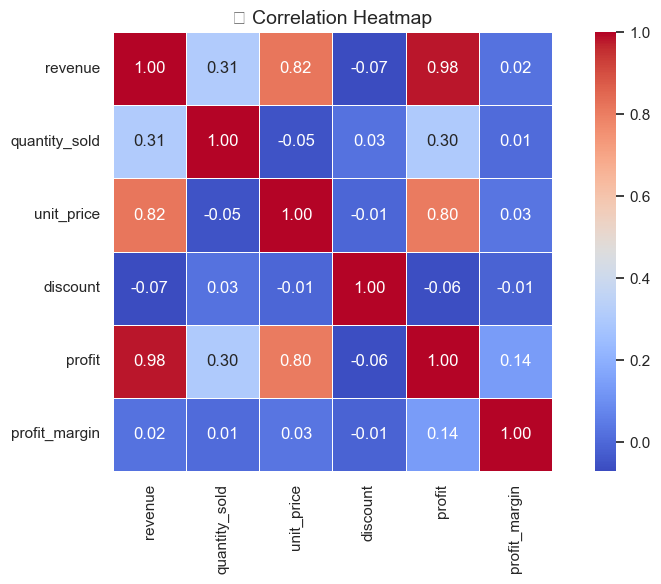

In [9]:
numeric_cols = ['revenue','quantity_sold','unit_price','discount','profit','profit_margin']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('🔥 Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Profit Margin Distribution

C:\Users\John\AppData\Local\Temp\ipykernel_19876\3937323297.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='profit_margin', ax=axes[1], palette='Set2')


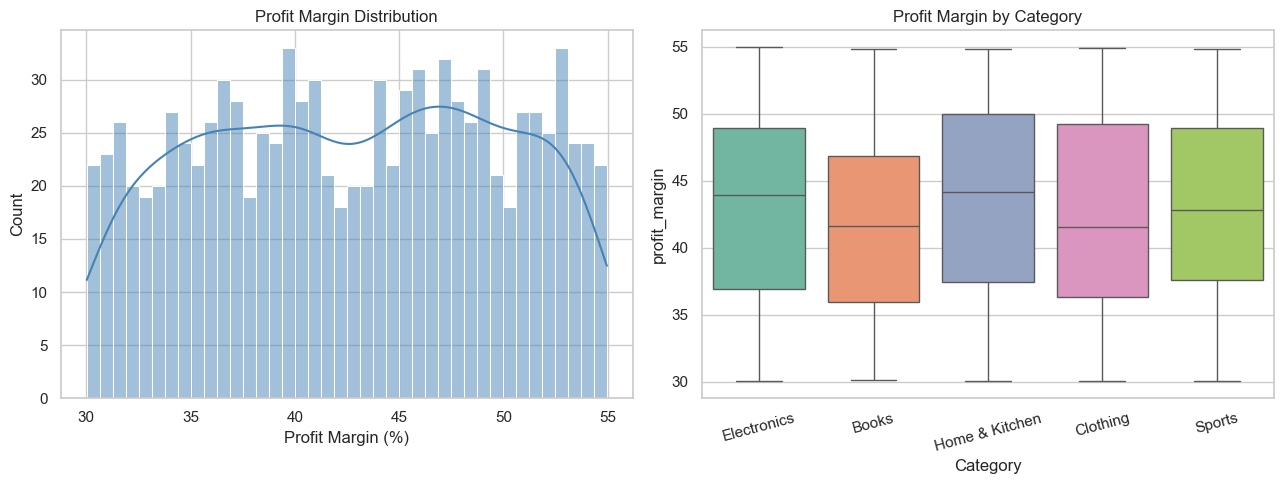

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['profit_margin'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Profit Margin Distribution')
axes[0].set_xlabel('Profit Margin (%)')

sns.boxplot(data=df, x='category', y='profit_margin', ax=axes[1], palette='Set2')
axes[1].set_title('Profit Margin by Category')
axes[1].set_xlabel('Category')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 10. Revenue Heatmap — Day of Week vs Month

C:\Users\John\AppData\Local\Temp\ipykernel_19876\2088445760.py:10: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\John\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


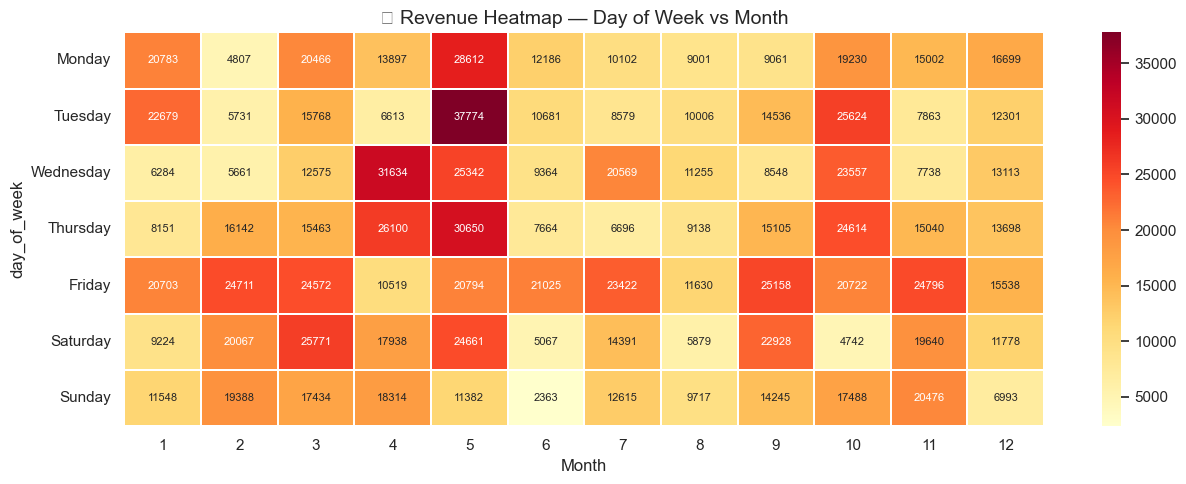

In [11]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.pivot_table(values='revenue', index='day_of_week',
                       columns='month', aggfunc='sum')
pivot = pivot.reindex(day_order)

plt.figure(figsize=(13, 5))
sns.heatmap(pivot, cmap='YlOrRd', fmt='.0f', linewidths=0.3, annot=True, annot_kws={'size':8})
plt.title('📅 Revenue Heatmap — Day of Week vs Month', fontsize=14)
plt.xlabel('Month')
plt.tight_layout()
plt.show()

## 11. Discount vs Profit Margin

In [12]:
fig = px.scatter(df, x='discount', y='profit_margin',
                 color='category', size='revenue',
                 title='💸 Discount vs Profit Margin by Category',
                 labels={'discount':'Discount Rate','profit_margin':'Profit Margin (%)'})
fig.show()

## 12. RFM Customer Segmentation

In [13]:
snapshot = df['order_date'].max()

rfm = df.groupby('customer_id').agg(
    Recency   = ('order_date',   lambda x: (snapshot - x.max()).days),
    Frequency = ('order_id',     'count'),
    Monetary  = ('revenue',      'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4])
rfm['RFM_Total'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

def segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal'
    elif score >= 5: return 'Potential'
    else: return 'At Risk'

rfm['Segment'] = rfm['RFM_Total'].apply(segment)

fig = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary',
                    color='Segment', size='Monetary',
                    title='👥 RFM 3D Customer Segmentation',
                    color_discrete_map={
                        'Champions':'green','Loyal':'blue',
                        'Potential':'orange','At Risk':'red'})
fig.show()
rfm['Segment'].value_counts()

Segment
Loyal        111
Champions     75
Potential     55
At Risk       47
Name: count, dtype: int64

## 13. NumPy Statistical Summary

In [14]:
print('=== Revenue Stats ===')
print(f'Mean:         ${np.mean(df["revenue"]):,.2f}')
print(f'Median:       ${np.median(df["revenue"]):,.2f}')
print(f'Std Dev:      ${np.std(df["revenue"]):,.2f}')
print(f'25th pct:     ${np.percentile(df["revenue"], 25):,.2f}')
print(f'75th pct:     ${np.percentile(df["revenue"], 75):,.2f}')
print(f'95th pct:     ${np.percentile(df["revenue"], 95):,.2f}')

yearly = df.groupby('year')['revenue'].sum()
if len(yearly) > 1:
    cagr = (yearly.iloc[-1] / yearly.iloc[0]) ** (1/(len(yearly)-1)) - 1
    print(f'\nRevenue CAGR: {cagr*100:.1f}%')

print('\n=== Profit Stats ===')
print(f'Total Profit: ${df["profit"].sum():,.2f}')
print(f'Avg Margin:   {df["profit_margin"].mean():.1f}%')
print(f'Best Margin:  {df["profit_margin"].max():.1f}%')

=== Revenue Stats ===
Mean:         $1,309.74
Median:       $582.16
Std Dev:      $1,843.92
25th pct:     $205.85
75th pct:     $1,573.31
95th pct:     $5,629.80

Revenue CAGR: 21.3%

=== Profit Stats ===
Total Profit: $563,090.25
Avg Margin:   42.8%
Best Margin:  55.0%


## 14. Quarterly Revenue by Category (Sunburst)

In [15]:
quarterly = df.groupby(['year','quarter','category'])['revenue'].sum().reset_index()
quarterly['label'] = quarterly['year'].astype(str) + ' Q' + quarterly['quarter'].astype(str)

fig = px.sunburst(quarterly, path=['label','category'], values='revenue',
                  color='revenue', color_continuous_scale='RdYlGn',
                  title='☀️ Quarterly Revenue Sunburst by Category')
fig.show()